In [137]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Course reminder

### Motivation:

Many machine learning problems, whether they be supervised or unsupervised, write as follows:

\begin{equation*}
\min_{f\in \mathcal{F}} \frac{1}{n}\sum_{i=1}^n \ell(f(x_i)) + \lambda \Omega(f)
\end{equation*}

for some hypothesis space $\mathcal{F}$ and some regularization $\Omega$.

Kernel methods allow to manipulate hypothesis spaces that are not only Hilbert Spaces but also enjoy the so-called reproducing property. 

### Kernels and RKHS:

As seen in the lecture, let us define a positive definite symmetric kernel $k : \mathbb{R}^d \times \mathbb{R}^d \mapsto \mathbb{R}$. 
Denote $\mathcal{H}_k$ its associated Reproducing Kernel Hilbert space ($\mathcal{H}$, $\langle \cdot, \cdot \rangle_{\mathcal{H}_k}$).

Let us recall that the following properties: for any $x\in \mathbb{R}^d$, we have:

$k(\cdot, x) \in \mathcal{H}_k$ \\
for any $f \in \mathcal{H}_k$,~$f(x) = \langle f, k(\cdot,x) \rangle_{\mathcal{H}_k}$ 

In praticular, $k(x,z) = \langle k(\cdot, x), k(\cdot, z) \rangle_{\mathcal{H}_k}$ 

In the remaining part of the document, we use refer to $k(\cdot, x)$ as the canonical feature map defined as:      
\begin{equation*}
\phi(x) = k(\cdot, x)
\end{equation*}

Learning within RKHSs means that we choose as hypothesis space this functional space. An interesting choice for $k$ is to pick up the Gaussian kernel:
    \begin{equation*}
    k(x,z)= \exp(-\gamma \| x - z\|^2).
    \end{equation*}
    
Indeed, the Gaussian kernel is said to be universal, i.e. the associated RKHS $\mathcal{H}_k$ is dense into the space of continuous real-valued functions.



# I. Basic kernel manipulations

Notations:

- $x_1,\ldots,x_n$ are the training point in $\mathbb{R}^d$. 
- The matrix $X$ is defined as $X = [x_1^T,...,x_n^T]$
- Similarly $z_1,...,z_m$ are the test points and $Z = [z_1^T,...,z_m^T]$
- We denote $K^{xx}$ the gram matrix of the train set that is $K^{xx}_{i,j} = k(x_i,x_j)$. When there is no ambiguity we simply denote it $K$.
- We denote $K^{xz}$ the train/test product matrix that is $K^{xz}_{i,j} = k(x_i,z_j)$

Q1) Prove that the linear kernel is a kernel 

$$k(x,y) = \langle x, y \rangle$$

The most popular/common kernel is the gaussian kernel 

$$k(x,y) = \exp\left(-\frac{||x-y||_2^2}{\sigma^2}\right)$$

The linear kernel is a kernel because:
1. It is symmetric: $k(x,y) = k(y,x)$ for all $x,y \in \mathbb{R}^d$ since it's an inner product.
2. It is positive definite: For any finite set of points $\{x_1, x_2, ..., x_n\}$ in $\mathbb{R}^d$ and any set of coefficients $\{c_1, c_2, ..., c_n\}$ in $\mathbb{R}$, we have:
   $\sum_{i=1}^n \sum_{j=1}^n c_i c_j k(x_i, x_j) = \sum_{i=1}^n \sum_{j=1}^n c_i c_j \langle x_i, x_j \rangle = \left\langle \sum_{i=1}^n c_i x_i, \sum_{j=1}^n c_j x_j \right\rangle = \left\| \sum_{i=1}^n c_i x_i \right\|^2 \geq 0$
   This shows that the kernel is positive definite.

Therefore the linear kernel is a kernel.

Q2) Let us prove that this is a valid kernel as well. Assume $d=1$ and $\sigma = 1$ to simplify.

- Step 1: Prove that $k(x,y) = (xy)^k$ is a kernel
- Step 2: use that a linear combinaison of kernels is kernel to prove that $k(x,y) = \sum_{k=0}^n (xy)^k$ is a kernel
- Step 3: use that a limit of kernels is kernel to prove that $k(x,y) = \exp(xy)$ is a kernel
- Step 4: conclude



Step 1: $k(x,y) = (xy)^k$ is a kernel.

$k(x,y) = (xy)^k= x^k y^k$. The feature map is $\phi(x) = x^k$. Then $k(x,y) = (xy)^k = x^k y^k = \langle \phi(x), \phi(y) \rangle$, which is clearly an inner product (linear, symetric and positive definite), hence a valid kernel.

Step 2: $k(x,y) = \sum_{k=0}^n (xy)^k$ is a kernel.

A finite non-negative linear combination of kernels is a kernel. Since each $(xy)^k$ is a kernel, the sum is a kernel.

Step 3: $k(x,y) = \exp(xy)$ is a kernel.

By the Taylor series: $\exp(xy) = \sum_{n=0}^{\infty} \frac{(xy)^n}{n!} = \lim_{N\to\infty} \sum_{n=0}^{N} \frac{(xy)^n}{n!}$.

A pointwise limit of kernels is a kernel. Here we have the limit of a sequence of kernels, so $\exp(xy)$ is a kernel.

Step 4: Conclude.

$$k(x,y) = \exp\!\left(-\|x-y\|^2\right) = \exp(-x^2)\exp(2xy)\exp(-y^2)$$

The factor $\exp(-x^2)\exp(-y^2)$ is a product of functions of $x$ and $y$ alone: $k(x,y) = g(x) \cdot \exp(2xy) \cdot g(y)$ with $g(x) = e^{-x^2}$.

Since $\exp(2xy)$ is a kernel (by Step 3 with argument $2xy$), and multiplying a kernel by $g(x)g(y)$ preserves the kernel property the Gaussian kernel is a valid kernel. 
Indeed,

Symmetry still holds since $g(x)g(y)$ is symmetric.
Positive definiteness is preserved because for any sequence of constants $c_1,...,c_n$:
$$\sum_{i=1}^n \sum_{j=1}^n c_i c_j k_{new}(x_i, x_j) \geq 0$$

$$= \sum_{i=1}^n \sum_{j=1}^n c_i c_j \Big[ g(x_i) k(x_i, x_j) g(x_j) \Big]$$

$$= \sum_{i=1}^n \sum_{j=1}^n \Big(c_i g(x_i)\Big) \Big(c_j g(x_j)\Big) k(x_i, x_j)$$

Let's define $c'_i = c_i g(x_i)$ et $c'_j = c_j g(x_j)$. We get:

$$= \sum_{i=1}^n \sum_{j=1}^n c'_i c'_j k(x_i, x_j)$$

Since $k(x_i, x_j)$ is a kernel, its matrix is semi-definite positive for **any** sequence of real numbers. Therefore, for our new sequence of constants $c'$, the fundamental condition is still satisfied:

$$\sum_{i=1}^n \sum_{j=1}^n c'_i c'_j k(x_i, x_j) \geq 0$$

The property of semi-definiteness is thus perfectly preserved.

Q3) For any $f \in \mathcal{H}$ of the form  $f = \sum_{i=1}^n \alpha_i \phi(x_i)$,  compute $||f||_\mathcal{H}^2$. Compute the expressions of:

- The norm: $||f||_\mathcal{H}^2$. It should depend only on $K$ and $\alpha$.
- The train prediction vector: $[f(x_1),...,f(x_n)]$. Idem.
- The test prediction vector: $[f(z_1),...,f(z_m)]$. It should depend only on $K^{x,z}$ and $\alpha$.

For $f = \sum_{i=1}^n \alpha_i \phi(x_i)$:

The norm:
$$\|f\|_{\mathcal{H}}^2 = \left\langle \sum_i \alpha_i \phi(x_i),\ \sum_j \alpha_j \phi(x_j) \right\rangle_{\mathcal{H}} = \sum_{i,j} \alpha_i \alpha_j k(x_i, x_j) = \alpha^\top K \alpha$$

The train prediction vector:
$$f(x_i) = \langle f, \phi(x_i) \rangle_{\mathcal{H}} = \sum_j \alpha_j k(x_j, x_i) = (K\alpha)_i$$

So $[f(x_1), \ldots, f(x_n)]^\top = K\alpha$.

The test prediction vector:
$$f(z_j) = \langle f, \phi(z_j) \rangle_{\mathcal{H}} = \sum_i \alpha_i k(x_i, z_j) = \bigl((K^{x,z})^\top \alpha\bigr)_j$$

So $[f(z_1), \ldots, f(z_m)]^\top = (K^{x,z})^\top \alpha$.


Q4) Complete the following code (application of the previous questions)

In [138]:
class Kernel():
    
    def compute_norm_f(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            norm_f: float
        '''
        norm_f = alpha @ Kxx @ alpha
        return norm_f
    
    def compute_prediction_train(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (n)
        '''
        y = Kxx @ alpha
        return y
    
    def compute_prediction_test(self, Kxz, alpha):
        '''
        Input: 
            Kxz: numpy array of shape (n, m)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (m)
        '''
        y = Kxz.T @ alpha
        return y


class GaussianKernel(Kernel):
    
    def __init__(self, sigma=1):
        self.sigma = sigma
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: numpy array of shape (n, n)
        '''
        sq_dists = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=-1)
        Kxx = np.exp(-sq_dists / self.sigma ** 2)
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: numpy array of shape (n, m)
        '''
        sq_dists = np.sum((X[:, None, :] - Z[None, :, :]) ** 2, axis=-1)
        Kxz = np.exp(-sq_dists / self.sigma ** 2)
        return Kxz


class LinearKernel(Kernel):
    
    def __init__(self):
        pass
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: numpy array of shape (n, n)
        '''
        Kxx = X @ X.T
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: numpy array of shape (n, m)
        '''
        Kxz = X @ Z.T
        return Kxz

# II. Centering data in a RKHS

Many ML algorithm expect the data to be centered i.e. $\overline{x} = \frac{1}{n} \sum_{i=1}^n x_i = 0$. When it is not the case we simply define a new centered dataset 

$$ x_i' = x_i - \overline{x}$$



Simarly, in kernel methods we often expect the data to be centered in the RKHS that is $ \overline{\phi} = \frac{1}{n} \sum_{i=1}^n \phi(x_i) = 0$. We can once again define some new data that is centered:

$$ \phi_i = \phi(x_i) - \overline{\phi}$$

The only difficulty is that the new points in the feature space might not correspond to any point in the original space i.e. they might not be any $x_i'$ such that $\phi(x_i') = \phi_i$.

Is it a problem ? No ! Remember that the strenght of the kernels methods is that we only need to compute the gram matrix to apply them.

Q1) Compute $\langle \phi_k,\phi_l \rangle_\mathcal{H}$ as a function of the $k(x_i,x_j)$

Let $\bar{\phi} = \frac{1}{n}\sum_{i=1}^n \phi(x_i)$, so $\phi_k = \phi(x_k) - \bar{\phi}$.

$$\langle \phi_k, \phi_l \rangle_{\mathcal{H}} = \langle \phi(x_k) - \bar{\phi},\ \phi(x_l) - \bar{\phi} \rangle_{\mathcal{H}}$$

$$= k(x_k, x_l) - \frac{1}{n}\sum_{j=1}^n k(x_j, x_l) - \frac{1}{n}\sum_{i=1}^n k(x_k, x_i) + \frac{1}{n^2}\sum_{i,j=1}^n k(x_i, x_j)$$

Q2) Give an expression of $K_c$ the gram matrix of the $\phi_i$ using only matrix multiplications, the original gram matrix $K$ and $\mathbf{1}_n$ the $n\times n$ matrix full of ones.

Let $J_n = \frac{1}{n}\mathbf{1}_n$ (where $\mathbf{1}_n$ is the $n\times n$ matrix with 1 at all coefficients). Then each term in Q1 corresponds to a matrix operation:

$$K_c = K - J_n K - K J_n + J_n K J_n = (I - J_n)\, K\, (I - J_n)$$

where $I$ is the $n\times n$ identity matrix.

Q3) Lets now assume that we want to center the test set (using the same mean !). That is we define 

$$\phi_i' = \phi(z_i) - \overline{\phi}$$

Compute the $\langle \phi_k', \phi_l \rangle_\mathcal{H}$ as a function of the $k(x_i,x_j)$ and $k(x_i,z_j)$.

Let $\phi_l = \phi(x_l) - \bar{\phi}$ and $\phi'_k = \phi(z_k) - \bar{\phi}$.

$$\langle \phi'_k, \phi_l \rangle_{\mathcal{H}} = \langle \phi(z_k) - \bar{\phi},\ \phi(x_l) - \bar{\phi} \rangle_{\mathcal{H}}$$

$$= k(z_k, x_l) - \frac{1}{n}\sum_{j=1}^n k(x_j, x_l) - \frac{1}{n}\sum_{i=1}^n k(z_k, x_i) + \frac{1}{n^2}\sum_{i,j=1}^n k(x_i, x_j)$$

Q4) Give an expression of $K^{x,z}_c$ the gram matrix of the $\langle \phi_k', \phi_l \rangle_\mathcal{H}$ using $K^{x,x}, K^{x,z}$ and $\mathbf{1}_n$.

Let $J_n = \frac{1}{n}\mathbf{1}_{n\times n}$ and $\mathbf{1}_{n\times m}$ be the $n\times m$ all-ones matrix. The four terms from Q3 give:

$$K^{xz}_c = K^{xz} - J_n\, K^{xz} - K^{xx}\,\frac{\mathbf{1}_{n\times m}}{n} + J_n\, K^{xx}\,\frac{\mathbf{1}_{n\times m}}{n}$$

Defining $J_{n,m} = \frac{1}{n}\mathbf{1}_{n\times m}$:

$$K^{xz}_c = K^{xz} - J_n K^{xz} - K^{xx} J_{n,m} + J_n K^{xx} J_{n,m}$$

Q5) Complete the following code

In [139]:
def center_train_gram_matrix(Kxx):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
    Output:
        Kxx_c: numpy array of shape (n, n)
    '''
    n = Kxx.shape[0]
    Jn = np.ones((n, n)) / n
    Kxx_c = Kxx - Jn @ Kxx - Kxx @ Jn + Jn @ Kxx @ Jn
    return Kxx_c

def center_test_gram_matrix(Kxx, Kxz):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
        Kxz: numpy array of shape (n, m)
    Output:
        K_c: numpy array of shape (n, m)
    '''
    n = Kxx.shape[0]
    m = Kxz.shape[1]
    Jn = np.ones((n, n)) / n
    Jnm = np.ones((n, m)) / n
    Kxz_c = Kxz - Jn @ Kxz - Kxx @ Jnm + Jn @ Kxx @ Jnm
    return Kxz_c

# III. Kernel PCA

## Reminder on PCA:


$\def\norm#1{\|#1\|}\def\pair#1{\langle #1 \rangle}\def\set#1{\lbrace#1\rbrace}$
$\def\RR{\mathbf{R}}$
$\def\trace{\operatorname{trace}}$

PCA is an unsupervised Machine Learning technique that learns a low-dimentional representation of the data.


We have a set $x_1,\ldots, x_n$ of vectors in $\RR^d$.

We project them to a lower dimention subspace spanned by the orthonormal vectors $v_1,\ldots,  v_m$.
For a single vector $x$, the projection is 
$$
 P_V(x_i) = \sum_{i=1}^m \pair{x, v_i} v_i
$$
In matrix form, the orthogonal projection onto the span of $v$ is

$$
 P_V = V^TV
$$
where 
$
 V = \lbrack v_1, \dots,  v_m \rbrack^T
$
satisfies $VV^T = I_m$. (since the $v_j$ are orthonormal).

In PCA, we try to find a subspace of dimension $m$ such that the projection on this subspace is as close as possible to the original data, that is we solve:

$$
\min_{V} \frac{1}{2}\norm{X - V^TVX}^2
$$
over the orthonormal matrices $V$.
Apply pythagoria's theorem to split the norm:
$$
\frac{1}{2}\norm{X - V^TVX}^2 = \quad \frac{1}{2}\norm{X}^2 + \frac{1}{2}\norm{V^TV X}^2 - \pair{X, V^TVX}.
$$

The first term is constant with respect to $V$.
The second term is equal to $(1/2)\norm{V X}^2$ by isometry, and the last term 
is $-\norm{VX}^2$.

Therfore the objective is also
$$
    \max_{V} \norm{VX}^2 = \max_{V} \trace{VX^TXV^T}
$$

We can show that in the last expression that $V$ is the top $m$-components of the 
eigen decomposition of $XX^T$.

## PCA in a RKHS

$\def\norm#1{\|#1\|}\def\pair#1{\langle #1 \rangle}\def\set#1{\lbrace#1\rbrace}$
$\def\RR{\mathbf{R}}$
$\def\trace{\operatorname{trace}}$
$\def\XX{\mathcal{X}}\def\HH{\mathcal{H}_k}$

We can proceed as before except that we try to find a $m$ dimensional representation of the vectors in the RKHS $\phi(x_1),...,\phi(x_n)$. The only difficulty is that those vectors are of infinite dimensions. 

Let's first focus on the projection over a single vector ($m=1$). For a  unitary vector $f\in \HH$, $\norm{f}^2_{\mathcal{H}_k} = 1$, we can still define the projection 
$$
P_f: \HH\to \HH ,\ g \mapsto \pair {g, f}_{\mathcal{H}_k}f
$$
And the optimal vector is 
$$
f^* = \arg \min_{f \in \HH, \| f\|_{\HH} = 1} \sum_{i=1}^n || P_f(\phi(x_i)) - \phi(x_i)||_{\HH}^2
$$

Q1) Prove that 

$$
f^* = \arg \max_{f \in \HH, \|f\|_{\HH} = 1} \sum_{i=1}^n f(x_i)^2
$$

(Tip: remember the reproducing property !)

Starting from the reconstruction error:

$$\sum_{i=1}^n \|P_f(\phi(x_i)) - \phi(x_i)\|_{\mathcal{H}}^2 = \sum_{i=1}^n \left(\|\phi(x_i)\|_{\mathcal{H}}^2 - \langle \phi(x_i), f\rangle_{\mathcal{H}}^2\right)$$

The first term $\sum_i \|\phi(x_i)\|^2$ is constant in $f$, so minimizing the reconstruction error is equivalent to:

$$f^* = \arg\max_{f,\,\|f\|_{\mathcal{H}}=1} \sum_{i=1}^n \langle \phi(x_i), f \rangle_{\mathcal{H}}^2$$

By the reproducing property, $\langle \phi(x_i), f \rangle_{\mathcal{H}} = \langle k(\cdot, x_i), f \rangle_{\mathcal{H}} = f(x_i)$.

Therefore:
$$f^* = \arg\max_{f,\,\|f\|_{\mathcal{H}}=1} \sum_{i=1}^n f(x_i)^2$$

Q2) Let's prove a variant of the representer theorem for this new optimization problem. We split $\HH$ into the span of the $\phi(x_1),\ldots,\phi(x_n)$ and its complement, that is for each $f \in \mathcal{H}$ we denote 

$$ f = f_X + f_\bot$$

where $f_X = \sum \alpha_i \phi(x_i)$ and $\langle f_\bot, f_X \rangle = 0$.

Prove the representer theorem i.e. that the optimal $f$ satisfies $f = f_X$.

We have $f = f_X + f_\perp$ with $f_X = \sum_i \alpha_i \phi(x_i)$ and $\langle f_\perp, \phi(x_i)\rangle_{\mathcal{H}} = 0$ for all $i$.

By the reproducing property, $f(x_i) = \langle f, \phi(x_i)\rangle_{\mathcal{H}} = \langle f_X, \phi(x_i)\rangle_{\mathcal{H}} + \langle f_\perp, \phi(x_i)\rangle_{\mathcal{H}} = f_X(x_i)$.

So $\sum_i f(x_i)^2 = \sum_i f_X(x_i)^2$, which does not depend on $f_\perp$.

By orthogonality of the decomposition,
$$\|f\|_{\mathcal{H}}^2 = \|f_X\|_{\mathcal{H}}^2 + \|f_\perp\|_{\mathcal{H}}^2 = 1$$

Since $\|f_\perp\|_{\mathcal{H}}^2 \geq 0$, we have $\|f_X\|_{\mathcal{H}}^2 \leq 1$, which means adding $f_\perp$ only weakens the constraint without improving the objective. The optimum is achieved at $f_\perp = 0$, i.e., $f = f_X = \sum_i \alpha_i \phi(x_i)$.

Q3) Apply the representer theorem to get a optimization problem over $\alpha \in \mathbb{R}^n$. As always the problem should depend only on $\alpha$ and the kernel matrix $K$.

We have $f = \sum_i \alpha_i \phi(x_i)$, and from Q3 of Section I we know that:

- $f(x_i) = (K\alpha)_i$, so $\sum_i f(x_i)^2 = \|K\alpha\|^2 = \alpha^\top K^2 \alpha$
- $\|f\|_{\mathcal{H}}^2 = \alpha^\top K \alpha$

The optimization problem becomes:

$$\max_{\alpha \in \mathbb{R}^n,\; \alpha^\top K \alpha = 1}\ \alpha^\top K^2 \alpha$$

Q4) Use the change of variable $\beta = \sqrt{K} \alpha$ to rewrite the problem as an eigenvalue problem.

Let $\beta = K^{1/2}\alpha$, i.e., $\alpha = K^{-1/2}\beta$. Then:

- $\alpha^\top K \alpha = \beta^\top K^{-1/2} K K^{-1/2} \beta = \|\beta\|^2$
- $\alpha^\top K^2 \alpha = \beta^\top K^{-1/2} K^2 K^{-1/2} \beta = \beta^\top K \beta$

The problem becomes:

$$\max_{\beta,\; \|\beta\|=1}\ \beta^\top K \beta$$

This is the standard eigenvalue problem for $K$. The optimal $\beta_j$ are the top eigenvectors of $K$ (the centered gram matrix $K_c$).


Q5) Let's say that we have found the $m$ principal vectors $f_1,...,f_m$ and that they all have the form

$$f_j = \sum_i \alpha_{i,j} \phi(x_i)$$

We are now given an new point $x$ (not necessarily in the train set). Give the expression of the $k$ principal components of $\phi(X)$:

$$ u(x)_j = \langle \phi(x), f_j \rangle_{\mathcal{H}_k}$$

Give the expression of vector $u(x)$ depending on the matrix $\alpha$ and the vector $k_x = [k(x,x_1),...,k(x,x_n)]$

The expression of vector u(x) is:
$$u(x)_j = \langle \phi(x), f_j \rangle_{\mathcal{H}} = \sum_i \alpha_{i,j} k(x, x_i) = \alpha^\top k_x$$

In conclusion, the algorithm for kernel PCA is :

* compute the gram matrix and center it.
* decompose it, keep the first $m$ eigenvectors, and eigenvalues.
* At a test point $x$, compute the $m$ principal components. (Don't forget to center the test points too!)

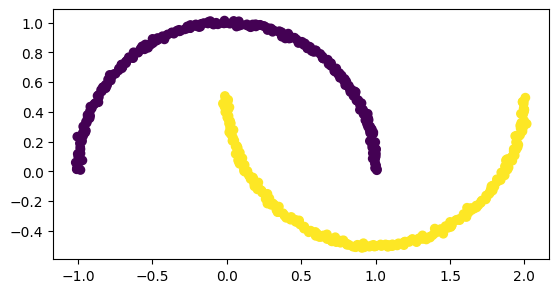

In [140]:
random_state = 17
n_samples = 500
X, y = make_moons(n_samples=n_samples, noise=0.01, random_state=random_state)
#X, y = make_circles(n_samples=n_samples, noise=0.01, factor=0.3, random_state=random_state)
#X, y = make_blobs(n_samples=n_samples, centers=3, cluster_std=1.0, random_state=random_state)

fig, ax = plt.subplots()
_ = ax.scatter(X[:,0], X[:,1], c=y)
ax.set_aspect('equal')

In [141]:
def make_grid(n,X):
    """
        Generates a grid of points within the bounds of the given data.

        n : int
            The number of points along each dimension of the grid.
        X : numpy.ndarray
            A 2D array of shape (num_samples, 2) representing the input data.

        numpy.ndarray
            A 2D array of shape (n*n, 2) containing the grid points.
    """
    x_min, y_min = np.min(X, axis=0)
    x_max, y_max = np.max(X, axis=0)
    xy = np.mgrid[x_min:x_max:1j*n, y_min:y_max:1j*n].reshape(2,-1).T
    return xy

In [142]:
# Hyperparameters (to be tuned)
#kernel_name = 'gaussian'  # test 'linear' or 'gaussian'
#sigma = 1
#lbda = 0.1

kernel_name = 'linear'  # test 'linear' or 'gaussian'
sigma = 1
lbda = 0.1

# Define kernel
if kernel_name == 'linear':
    kernel = LinearKernel()
elif kernel_name == 'gaussian':
    kernel = GaussianKernel(sigma=sigma)
else:
    raise ValueError('Unknown kernel')


def KPCA_representation(X):
    """
    Compute the finite-dimensional representation of the principal components.

    Parameters
    ----------
    X : (n, d) numpy.ndarray
        The input data.

    Returns
    -------
    alpha : (n, k) numpy.ndarray
        The finite-dimensional representation of the principal components.
        Each column alpha[:, j] = v_j / sqrt(d_j) where v_j is the j-th eigenvector
        of the centered gram matrix and d_j the associated eigenvalue.
    """
    
    Kxx = kernel.get_Kxx(X)
    Kxx_c = center_train_gram_matrix(Kxx)

    eigenvalues, eigenvectors = np.linalg.eigh(Kxx_c)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    pos_mask = eigenvalues > 1e-10
    eigenvalues = eigenvalues[pos_mask]
    eigenvectors = eigenvectors[:, pos_mask]

    alpha = eigenvectors / np.sqrt(eigenvalues)[None, :]

    return alpha

In [143]:
def principal_component(alpha, X, Z):
    """
    Return the evaluation of the principal components at points Z.

    Parameters
    ----------
    alpha : (n, k) numpy.ndarray
        The finite-dimensional representation of the principal components.
    X : (n, d) numpy.ndarray
        The training data.
    Z : (m, d) array
        Points where to evaluate the principal components.

    Returns
    -------
    (k, m) array
        Value of the k principal components at points Z.
    """
    
    Kxx = kernel.get_Kxx(X)
    Kxz = kernel.get_Kxz(X, Z)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)

    return alpha.T @ Kxz_c

In [144]:
n_eval = 200
Z = make_grid(n_eval, X)

alpha = KPCA_representation(X)
principal_component_fn = lambda E: principal_component(alpha, X, E)
feval = principal_component_fn(Z)
fself = principal_component_fn(X)

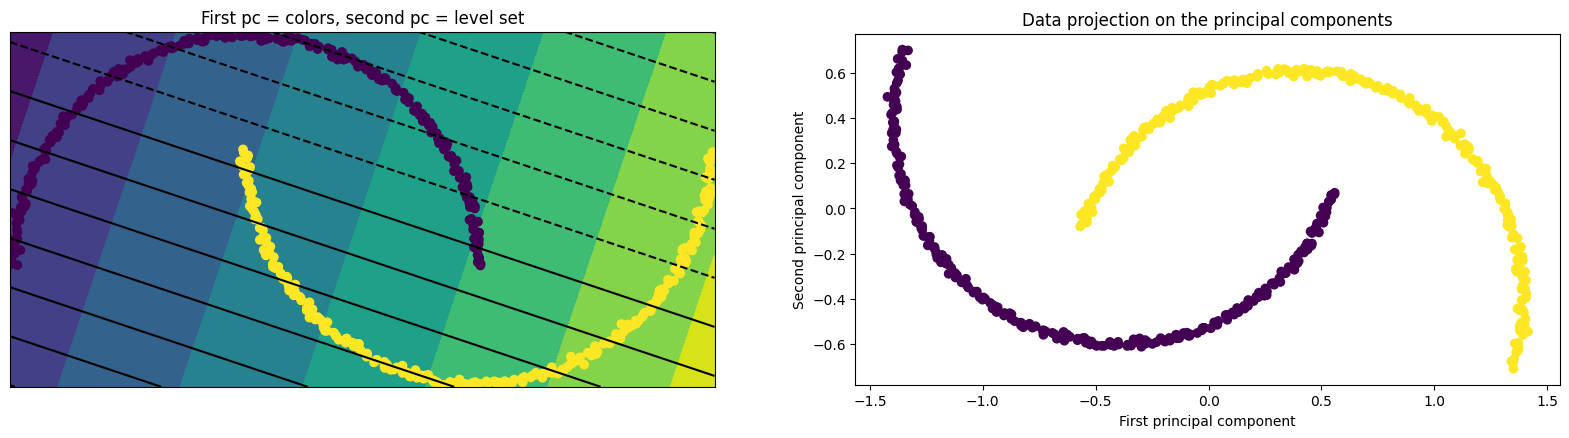

In [145]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
Ep = Z.T.reshape((2, n_eval, n_eval))
fxp = feval.reshape((feval.shape[0], n_eval, n_eval))
_ = ax1.contourf(Ep[0], Ep[1], fxp[0])
_ = ax1.contour(Ep[0], Ep[1], fxp[1], colors='black', levels=12 )
_ = ax1.scatter(X[:,0], X[:,1], c=y)
ax2.scatter(fself[0], fself[1], c=y)
ax1.xaxis.set_visible(False)
ax1.yaxis.set_visible(False)
#ax2.xaxis.set_visible(False)
#ax2.yaxis.set_visible(False)
ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax1.set_title('First pc = colors, second pc = level set')
ax2.set_title('Data projection on the principal components')
ax2.set_xlabel('First principal component')
ax2.set_ylabel('Second principal component')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.show()


## Solving Regression under contamination

In real-world problems, it is not rare to observe outliers in collected data. For instance, this happens when a sensor has a default or faces some specific event such as an accident. In statistics, Huber (1964) proposed to describe this kind of situation with the framework of contamination. A data is polluted by a mixture of a (classic) Gaussian noise with a small variance and an arbitray distribution that represent contaminations. In this practical session, we propose to study regression under contamination, meaning that the output training data are contaminated as follows:

\begin{equation*}
y_i = f^*(x_i) + \delta_i \epsilon_i + ( 1 - \delta_i) u_i,
\end{equation*}
where $\epsilon_i \sim \mathcal{N}(0,\sigma^2)$ is a Gaussian noise, $\delta_i \sim \mathcal{B}(p)$ is a Bernoulli variable, with $0 < p < 1$
and $u_i \sim Un([-b,+b])$, with $b > 0$, is a uniform variable.


We consider the general regression problem with a RKHS $\mathcal{H}_k$.
The **representer theorem** garantees that the solution of any problem of the form 

\begin{equation*}
\min_{f\in \mathcal{H}_k} \frac{1}{n}\sum_{i=1}^n \ell(f(x_i),y_i) + \lambda ||f||^2_{\mathcal{H}_k}
\end{equation*}

Can be written as

\begin{equation*}
\hat{f} = \sum_{i=1}^n \alpha_i \phi(x_i)
\end{equation*}

i.e.

\begin{equation*}
\hat{f}(x) = \sum_{i=1}^n \alpha_i k(x,x_i)
\end{equation*}

Meaning that finding the best function in $\mathcal{H}_k$ (which is infinite) is equivalent to find the right $\alpha \in \mathbb{R}^n$ !



Q6) Define a simple toy problem with $x$ and $y$ $\in \mathbb{R}$. For that, define a simple toy function $f^*$. Write the code to generate i.i.d. contaminated datasets $\{(x_i,y_i)\}_{i=1}^n$ for different values of $p$, $\sigma$ and $b$ for both training and test.

We choose the toy function $f^*(x) = \sin(2\pi x)$ on $x \in [0, 1]$.

The contaminated model is:
$$y_i = f^*(x_i) + \delta_i \varepsilon_i + (1 - \delta_i) u_i$$

with $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, $\delta_i \sim \mathcal{B}(p)$, $u_i \sim \text{Uniform}([-b, b])$.


Q7) Loss functions are not equal with respect to output contaminations. Consider the square loss $\ell_{square}(y,f(x)):= (y - f(x))^2$ and solve the so-called Kernel Ridge Regression problem. You can use the closed form solution (implement it) or the stochastic Gradient descent implementation of scikitlearn.

The problem is:
$$\min_{f \in \mathcal{H}_k} \frac{1}{n}\sum_{i=1}^n (f(x_i) - y_i)^2 + \lambda \|f\|_{\mathcal{H}}^2$$

By the representer theorem, $f = \sum_i \alpha_i \phi(x_i)$, so substituting the expressions from Section I:

$$\min_{\alpha \in \mathbb{R}^n} \frac{1}{n}\|K\alpha - y\|^2 + \lambda\, \alpha^\top K \alpha$$

Setting the gradient to zero: $\frac{2}{n}K(K\alpha - y) + 2\lambda K\alpha = 0$, which gives:

$$\hat{\alpha} = (K + n\lambda I)^{-1} y$$


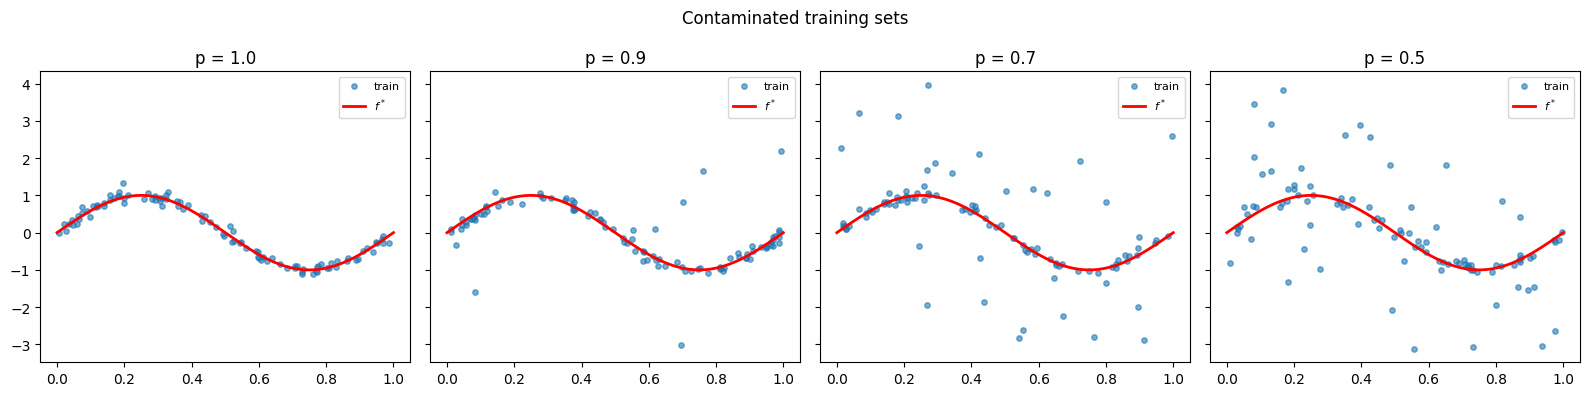

In [146]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def f_s(x):
    return np.sin(2 * np.pi * x)

def generate_contaminated_data(n, p=0.9, sigma=0.1, b=3.0):
    """
    Generate a contaminated dataset.
    p   : probability of clean observation (Bernoulli parameter)
    sigma: std of the Gaussian noise
    b   : half-range of the outlier uniform noise
    """
    x = np.random.uniform(0, 1, n)
    delta = np.random.binomial(1, p, n)
    eps = np.random.normal(0, sigma, n)
    u = np.random.uniform(-b, b, n)
    y = f_s(x) + delta * eps + (1 - delta) * u
    return x[:, None], y 

n_train = 100
n_test  = 200

# Training sets with different contamination levels
p_values = [1.0, 0.9, 0.7, 0.5]
datasets = {p: generate_contaminated_data(n_train, p=p) for p in p_values}
X_test, y_test = generate_contaminated_data(n_test, p=1.0)  # clean test set


fig, axes = plt.subplots(1, len(p_values), figsize=(16, 4), sharey=True)
x_plot = np.linspace(0, 1, 300)[:, None]
for ax, p in zip(axes, p_values):
    Xtr, ytr = datasets[p]
    ax.scatter(Xtr, ytr, s=15, alpha=0.6, label='train')
    ax.plot(x_plot, f_s(x_plot), 'r-', lw=2, label='$f^*$')
    ax.set_title(f'p = {p}')
    ax.legend(fontsize=8)
plt.suptitle('Contaminated training sets')
plt.tight_layout()
plt.show()

Q10) Let us consider the so-called $\epsilon$-insensitive loss:
   $$\ell_{\epsilon}(y,f(x)):= \max(0, |y - f(x)| -\epsilon)$$


Solve the Support Vector regression problem using this loss and squared norm penalty. There exist two ways to solve this problem: either i) you notice that the problem wriets as a convex programme with affine inequality constraint and dualize the problem (at some point we ned to use functional derivative of $f$ when deploying KKT), or ii) apply representer theorem and write the primal problem with $\alpha \in \mathbb{R}^n$. Introduce slack variables for the two types of errors (positive and negative): $\xi^+ \in \mathbb{R}^n$ and $\xi^- \in \mathbb{R}^n$. Then apply Lagrangian relaxation (KKT conditions) and write the problem  in the dual space. Choose one of the other way (split the classroom in two). Any way this leads to Support Vector Regression.
    


With $f = \sum_i \alpha_i k(\cdot, x_i)$, the $\epsilon$-insensitive SVR primal is:

$$\min_{\alpha, \xi^+, \xi^-} \frac{1}{n}\sum_{i=1}^n (\xi_i^+ + \xi_i^-) + \lambda\, \alpha^\top K \alpha$$

subject to: $\forall i$:
$$y_i - (K\alpha)_i \leq \epsilon + \xi_i^+, \quad (K\alpha)_i - y_i \leq \epsilon + \xi_i^-, \quad \xi_i^+, \xi_i^- \geq 0$$

Introducing Lagrange multipliers $\mu_i^+, \mu_i^- \geq 0$ for the inequality constraints and $\nu_i^+, \nu_i^- \geq 0$ for the positivity of slacks, the Lagrangian is:

$$\mathcal{L} = \frac{1}{n}\sum_i(\xi_i^+ + \xi_i^-) + \lambda\alpha^\top K\alpha + \sum_i \mu_i^+(y_i - (K\alpha)_i - \epsilon - \xi_i^+) + \sum_i \mu_i^-((K\alpha)_i - y_i - \epsilon - \xi_i^-) - \sum_i \nu_i^+ \xi_i^+ - \sum_i \nu_i^- \xi_i^-$$

KKT stationarity conditions:

$\partial_{\xi_i^\pm}: \frac{1}{n} - \mu_i^\pm - \nu_i^\pm = 0 \Rightarrow 0 \leq \mu_i^\pm \leq \frac{1}{n}$

$\partial_\alpha: 2\lambda K\alpha - K(\mu^+ - \mu^-) = 0 \Rightarrow \alpha = \frac{1}{2\lambda}(\mu^+ - \mu^-)$

Dual problem: Substituting back into the Lagrangian gives the dual:

$$\max_{\mu^+, \mu^-} -\lambda\, (\mu^+ - \mu^-)^\top K (\mu^+ - \mu^-) - \epsilon \mathbf{1}^\top(\mu^+ + \mu^-) + y^\top(\mu^+ - \mu^-)$$

subject to $0 \leq \mu_i^\pm \leq \frac{1}{n}$.

This is a quadratic program (QP) equivalent to the standard SVR dual formulation, solvable by `sklearn.svm.SVR`.

Q11) First study the behaviour of SVR depending on the choice of the hyperparameters $\epsilon$ and $\lambda$ on the toy problem without contaminations ($\delta_i=1$ is a dterminstic and constant.)

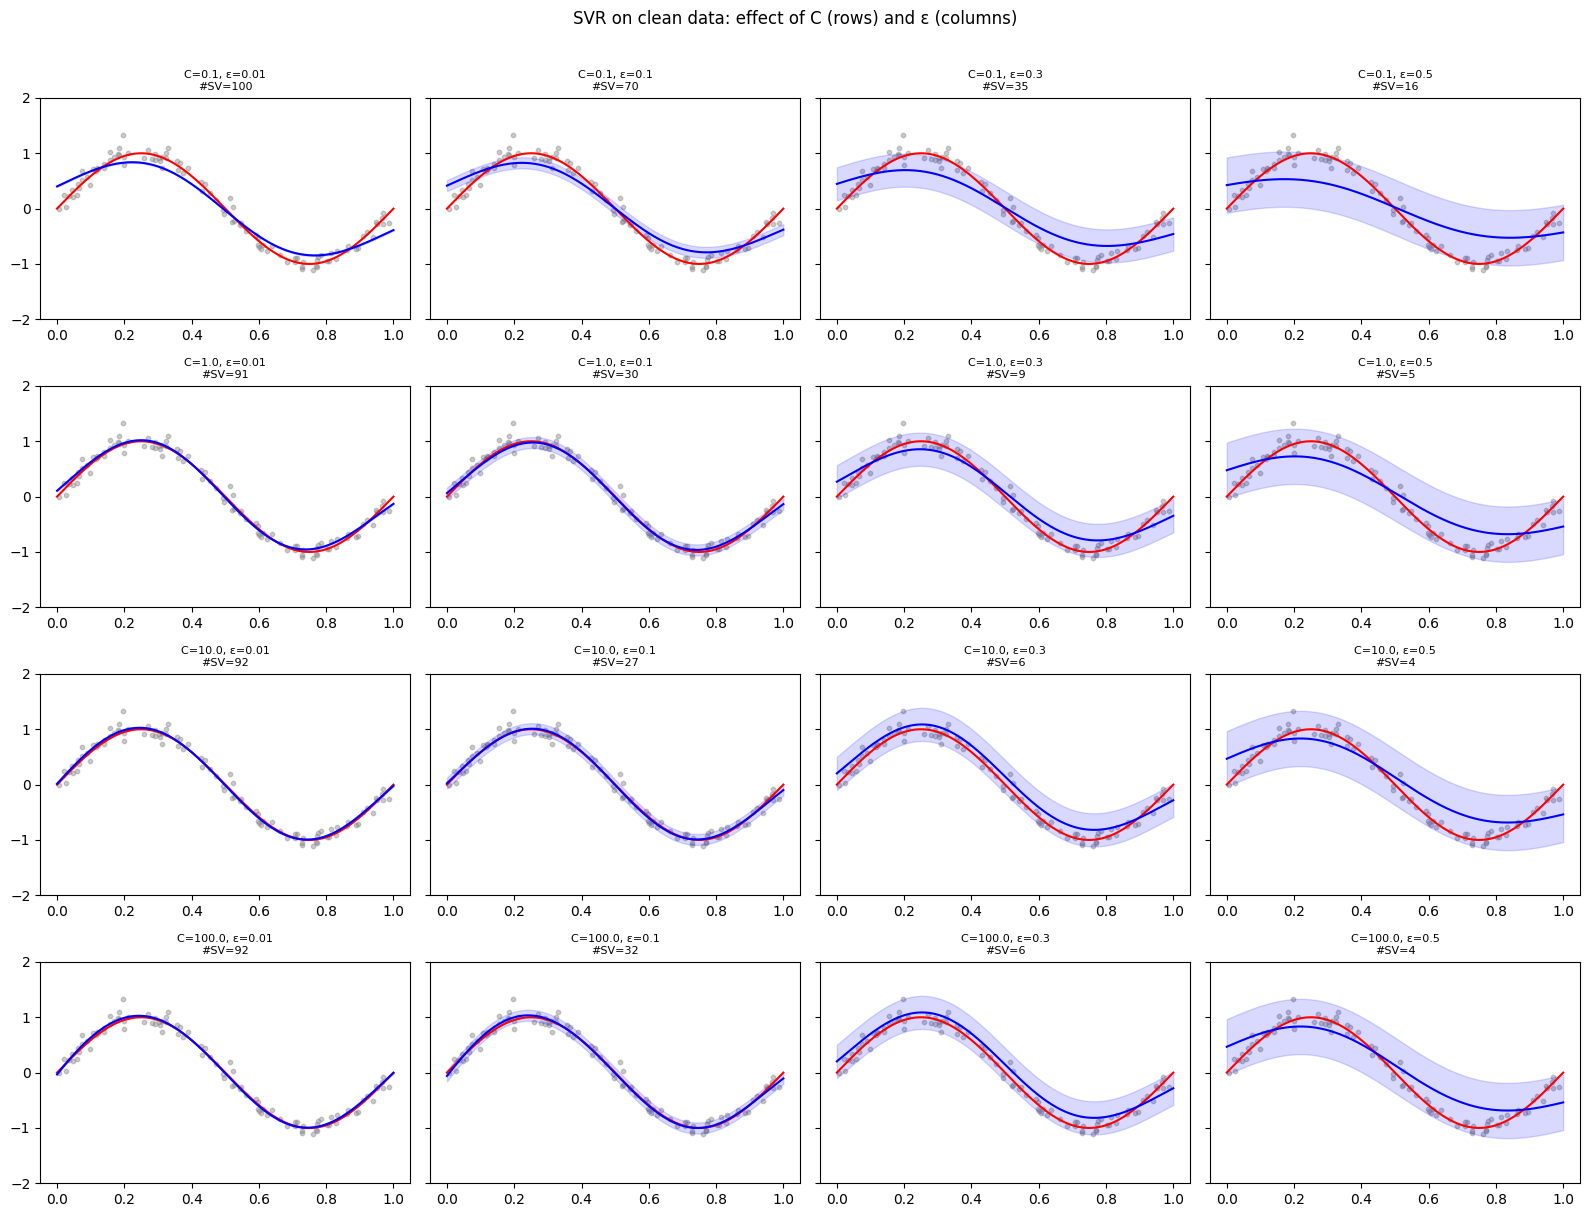

Observations:
- Large ε → wider insensitive tube → fewer support vectors, smoother fit
- Large C → small regularisation → fits data more tightly, more support vectors


In [147]:
from sklearn.svm import SVR as SklearnSVR

# Study SVR behaviour vs epsilon and C=1/(2*lambda) on CLEAN data
Xtr_clean, ytr_clean = datasets[1.0]

epsilon_values = [0.01, 0.1, 0.3, 0.5]
C_values = [0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(len(C_values), len(epsilon_values), figsize=(16, 12), sharey=True)

for i, C in enumerate(C_values):
    for j, eps in enumerate(epsilon_values):
        ax = axes[i, j]
        svr = SklearnSVR(kernel='rbf', gamma=1/(2*0.3**2), C=C, epsilon=eps)
        svr.fit(Xtr_clean, ytr_clean)
        y_curve = svr.predict(x_plot)
        n_sv = svr.support_vectors_.shape[0]

        ax.scatter(Xtr_clean, ytr_clean, s=10, alpha=0.4, color='gray')
        ax.plot(x_plot, f_s(x_plot), 'r-', lw=1.5)
        ax.plot(x_plot, y_curve, 'b-', lw=1.5)
        ax.fill_between(x_plot.ravel(), y_curve - eps, y_curve + eps,
                        alpha=0.15, color='blue')
        ax.set_ylim(-2, 2)
        ax.set_title(f'C={C}, ε={eps}\n#SV={n_sv}', fontsize=8)

plt.suptitle('SVR on clean data: effect of C (rows) and ε (columns)', y=1.01)
plt.tight_layout()
plt.show()

Larger $\epsilon$ means a wider tolerance tube: more points are considered “good enough” (no penalty), so fewer points become support vectors. The model ignores small deviations, giving a smoother, less sensitive fit.

Larger $C$ means weaker regularization (stronger penalty for errors): the model is pushed to reduce training errors more aggressively, so it follows the data more closely. This usually creates a tighter, less smooth fit with more support vectors.

So: $\epsilon$ controls tolerance, while $C$ controls strictness.

Q12) Now, use the result of Q6) to evaluate performance of SVR as compared to KKR on contaminated distributions. 
What can you say about the behaviour of SVR.



Using Q6, we get:

- **KRR** degrades quickly as contamination increases.
    - The squared loss strongly penalizes outliers.
    - A few large corrupted labels can pull the predictor far from the true function.

- **SVR** is more robust.
    - The $\epsilon$-insensitive loss ignores small residuals and grows only linearly outside the tube.
    - This makes the estimator much less sensitive to extreme outliers.

Conclusion

As contamination increases, SVR usually keeps a lower test error than KRR and preserves a better approximation of the clean target function.

So: SVR is more robust to label contamination than KRR.